# M3 Program
Fabian, Morgan, and Jack

## Approach

The Maximal Substring problem asks us to find the longest common substring between two strings `a` and `b`. A substring is a contiguous sequence of characters that must appear consecutively in both strings, unlike a subsequence which can have gaps.

Our approach builds on the observation that if we know the longest common substring **ending** at specific positions `i` in string `a` and `j` in string `b`, we can use this information to compute longer common substrings.

**Key Insight:** If `a[i] == b[j]`, then the longest common substring ending at these positions is one character longer than the longest common substring ending at `a[i-1]` and `b[j-1]`. Otherwise, there's no common substring ending at both positions (the value is 0).

**Illustration 1: DP Table for \"orange\" and \"banana\"**
```
      b  a  n  a  n  a
  o   0  0  0  0  0  0
  r   0  0  0  0  0  0
  a   0  1  0  1  0  1
  n   0  0  2  0  2  0
  g   0  0  0  0  0  0
  e   0  0  0  0  0  0
```
The maximum value is 2, corresponding to \"an\" (found at positions (3,2) and (3,4)).

**Illustration 2: DP Table for \"apple\" and \"pineapple\"**
```
      p  i  n  e  a  p  p  l  e
  a   0  0  0  0  1  0  0  0  0
  p   1  0  0  0  0  2  1  0  0
  p   1  0  0  0  0  1  2  0  0
  l   0  0  0  0  0  0  0  3  0
  e   0  0  0  1  0  0  0  0  4
```
Continuing the full table (5x9), we find the entire word \"apple\" matches at the end with length 5.

## Pseudocode

### Brute Force Backtracking
```
function maxSubstringBF(a, b, i, j):
    if i < 0 or j < 0:
        return 0
    
    if a[i] == b[j]:
        length_ending_here = 1 + maxSubstringBF(a, b, i-1, j-1)
    else:
        length_ending_here = 0
    
    skip_a = maxSubstringBF(a, b, i-1, j)
    skip_b = maxSubstringBF(a, b, i, j-1)
    
    return max(length_ending_here, skip_a, skip_b)
```

### Lazy Memoized Brute Force Backtracking
```
function maxSubstringMemo(a, b, i, j, memo):
    if i < 0 or j < 0:
        return 0
    
    if memo[i][j] is not None:
        return memo[i][j]
    
    if a[i] == b[j]:
        length_ending_here = 1 + maxSubstringMemo(a, b, i-1, j-1, memo)
    else:
        length_ending_here = 0
    
    skip_a = maxSubstringMemo(a, b, i-1, j, memo)
    skip_b = maxSubstringMemo(a, b, i, j-1, memo)
    
    memo[i][j] = max(length_ending_here, skip_a, skip_b)
    return memo[i][j]
```

### Eager Dynamic Programming
```
function maxSubstringDP(a, b):
    n = len(a)
    m = len(b)
    dp = array of size [n+1][m+1] initialized to 0
    max_length = 0
    
    for i = 1 to n:
        for j = 1 to m:
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
                max_length = max(max_length, dp[i][j])
            else:
                dp[i][j] = 0
    
    return max_length
```

## Justification of Correctness

### Brute Force Backtracking
The brute force algorithm explores all possible ending positions for substrings in both strings. For each position pair (i, j), it computes the length of the common substring ending at those positions. If `a[i] == b[j]`, the substring ending here extends the substring ending at (i-1, j-1) by one character. The algorithm recursively explores all positions by also considering positions (i-1, j) and (i, j-1), ensuring that no potential common substring is missed. By taking the maximum of all three options at each step, it correctly identifies the longest common substring.

### Lazy Memoized Brute Force Backtracking
This algorithm preserves the correctness of the brute force approach while eliminating redundant computations. The memoization table stores previously computed results for each (i, j) pair. Since the recursive structure is identical to the brute force version, it computes the same values—just more efficiently. The correctness argument is the same: we explore all positions and take the maximum length found. Memoization doesn't change the logic, only the execution order and efficiency.

### Eager Dynamic Programming
The dynamic programming solution computes results in a bottom-up manner, filling a table where `dp[i][j]` represents the length of the common substring ending at positions i-1 in string a and j-1 in string b. The recurrence relation is: if `a[i-1] == b[j-1]`, then `dp[i][j] = dp[i-1][j-1] + 1`; otherwise `dp[i][j] = 0`. This correctly captures that matching characters extend previous substrings, while non-matching characters break the substring (since substrings must be contiguous). By iterating through all positions and tracking the maximum value seen, we correctly identify the length of the longest common substring. The algorithm's correctness follows from the principle of optimal substructure: the optimal solution for position (i, j) depends only on the solution for (i-1, j-1).

## Implementation

In [ ]:
# Brute Force Backtracking
def max_substring_bf_helper(a, b, i, j):
    """Helper function for brute force backtracking."""
    # Base case
    if i < 0 or j < 0:
        return 0
    
    # If characters match, this substring extends from previous position
    if a[i] == b[j]:
        length_ending_here = 1 + max_substring_bf_helper(a, b, i-1, j-1)
    else:
        length_ending_here = 0
    
    # Also try skipping characters in either string
    skip_a = max_substring_bf_helper(a, b, i-1, j)
    skip_b = max_substring_bf_helper(a, b, i, j-1)
    
    return max(length_ending_here, skip_a, skip_b)

def max_substring_bf(a, b):
    """Brute force backtracking solution."""
    if not a or not b:
        return 0
    return max_substring_bf_helper(a, b, len(a)-1, len(b)-1)
# Brute Force Backtracking
def max_substring_bf(a, b):
    """Brute-force check: for every starting pair, expand forward while characters match."""
    if not a or not b:
        return 0
    n = len(a)
    m = len(b)
    maxl = 0
    for i in range(n):
        for j in range(m):
            k = 0
            while i + k < n and j + k < m and a[i + k] == b[j + k]:
                k += 1
            if k > maxl:
                maxl = k
    return maxl

In [ ]:
# Lazy Memoized Brute Force Backtracking (forward memoization)
def max_substring_memo(a, b):
    """Memoized forward recursion: helper(i,j) returns length of common prefix starting at i,j."""
    if not a or not b:
        return 0
    n = len(a)
    m = len(b)
    memo = [[None for _ in range(m)] for _ in range(n)]

    def helper(i, j):
        if i >= n or j >= m:
            return 0
        if memo[i][j] is not None:
            return memo[i][j]
        if a[i] == b[j]:
            memo[i][j] = 1 + helper(i+1, j+1)
        else:
            memo[i][j] = 0
        return memo[i][j]

    maxl = 0
    for i in range(n):
        for j in range(m):
            maxl = max(maxl, helper(i, j))
    return maxl

In [3]:
# Eager Dynamic Programming
def max_substring_dp(a, b):
    """Eager dynamic programming solution."""
    if not a or not b:
        return 0
    
    n = len(a)
    m = len(b)
    
    # Create DP table with extra row/column for base case
    dp = [[0 for _ in range(m + 1)] for _ in range(n + 1)]
    max_length = 0
    
    # Fill table bottom-up
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
                max_length = max(max_length, dp[i][j])
            else:
                dp[i][j] = 0
    
    return max_length

## Test Cases

In [ ]:
# Test Cases
import pandas as pd

test_cases = [
    # (string a, string b, expected length, description)
    ("orange", "banana", 2, "Example from problem: 'an'"),
    ("banana", "apple", 1, "Example from problem: 'a'"),
    ("apple", "pineapple", 5, "Example from problem: 'apple'"),
    ("pinaeapple", "orange", 1, "Example from problem: 'e' or 'a'"),
    ("", "test", 0, "Empty string a"),
    ("test", "", 0, "Empty string b"),
    ("", "", 0, "Both empty"),
    ("a", "a", 1, "Single character match"),
    ("a", "b", 0, "Single character no match"),
    ("abc", "def", 0, "No common substring"),
    ("abcdef", "abcdef", 6, "Identical strings"),
    ("abcdef", "fedcba", 1, "Reversed strings"),
    ("ABABC", "BABCA", 4, "Overlapping patterns: 'BABC'"),
    ("programming", "gaming", 4, "'ming'"),
    ("geeksforgeeks", "geeks", 5, "'geeks'"),
    ("abcdxyz", "xyzabcd", 4, "'abcd' or 'xyz'"),
    ("zxabcdezy", "yzabcdezx", 6, "'abcdez'"),
]

# Run tests and collect results
results = []
for a, b, expected, description in test_cases:
    bf_result = max_substring_bf(a, b) if len(a) <= 10 and len(b) <= 10 else "Skipped (too slow)"
    memo_result = max_substring_memo(a, b)
    dp_result = max_substring_dp(a, b)
    
    results.append({
        "String a": a[:20] + "..." if len(a) > 20 else a,
        "String b": b[:20] + "..." if len(b) > 20 else b,
        "Expected": expected,
        "BF Result": bf_result,
        "Memo Result": memo_result,
        "DP Result": dp_result,
        "Status": "✓PASS" if (bf_result == expected or bf_result == "Skipped (too slow)") and memo_result == expected and dp_result == expected else "✗FAIL",
        "Description": description
    })

# Display results table
df = pd.DataFrame(results)
print("Test Cases Results:")
print(df.to_string(index=False))
print(f"\nTests Passed: {sum(1 for r in results if r['Status'] == '✓PASS')}/{len(results)}")

Test Cases Results:
     String a  String b  Expected          BF Result  Memo Result  DP Result Status                      Description
       orange    banana         2                  2            2          2  ✓PASS       Example from problem: 'an'
       banana     apple         1                  1            1          1  ✓PASS        Example from problem: 'a'
        apple pineapple         5                  5            5          5  ✓PASS    Example from problem: 'apple'
   pinaeapple    orange         1                  2            2          1  ✗FAIL Example from problem: 'e' or 'a'
                   test         0                  0            0          0  ✓PASS                   Empty string a
         test                   0                  0            0          0  ✓PASS                   Empty string b
                                0                  0            0          0  ✓PASS                       Both empty
            a         a         1           

## Asymptotic Runtime

### Brute Force Backtracking
**Time Complexity: O(3^(n+m))**

At each recursive call, we make up to 3 recursive calls (for matching, skip_a, and skip_b). In the worst case, we explore all possible combinations of positions in both strings. The recursion tree has height proportional to n+m (we decrement either i or j at each level), and each node has 3 children, giving us O(3^(n+m)) time complexity.

**Space Complexity: O(n+m)** for the recursion call stack.

### Lazy Memoized Brute Force Backtracking
**Time Complexity: O(n×m)**

With memoization, each unique (i, j) pair is computed only once. There are n×m possible pairs, and each computation involves O(1) work (after recursive calls return from cache). Therefore, the time complexity is O(n×m).

**Space Complexity: O(n×m)** for the memoization table plus O(n+m) for the recursion stack, giving O(n×m) overall.

### Eager Dynamic Programming
**Time Complexity: O(n×m)**

We fill an (n+1)×(m+1) table using two nested loops. Each cell requires O(1) time to compute (just a comparison and possibly an addition). Therefore, the total time is O(n×m).

**Space Complexity: O(n×m)** for the DP table. This can be optimized to O(min(n,m)) by only keeping one or two rows at a time, but our implementation uses the full table.

## Benchmarking

In [5]:
# Run benchmarking tests
import time
import random
import string

def generate_random_string(length, alphabet_size=4):
    """Generate a random string of given length from a limited alphabet."""
    alphabet = string.ascii_lowercase[:alphabet_size]
    return ''.join(random.choice(alphabet) for _ in range(length))

def benchmark_algorithm(func, a, b, timeout=5.0):
    """Benchmark an algorithm with a timeout."""
    start = time.time()
    try:
        result = func(a, b)
        elapsed = time.time() - start
        if elapsed > timeout:
            return None, None  # Too slow
        return result, elapsed
    except Exception as e:
        return None, None

# Set random seed for reproducibility
random.seed(42)

# Test sizes
test_sizes = [
    (5, 5),
    (10, 10),
    (15, 15),
    (20, 20),
    (30, 30),
    (50, 50),
    (100, 100),
    (200, 200),
    (500, 500),
]

benchmark_results = []

print("Running benchmarks...")
for n, m in test_sizes:
    print(f"Testing size ({n}, {m})...")
    
    # Generate test strings
    a = generate_random_string(n)
    b = generate_random_string(m)
    
    # Benchmark brute force (only for small sizes)
    if n <= 10 and m <= 10:
        _, bf_time = benchmark_algorithm(max_substring_bf, a, b)
    else:
        bf_time = None
    
    # Benchmark memoized version
    _, memo_time = benchmark_algorithm(max_substring_memo, a, b)
    
    # Benchmark DP version
    _, dp_time = benchmark_algorithm(max_substring_dp, a, b)
    
    benchmark_results.append({
        'n': n,
        'm': m,
        'BF Time (s)': f"{bf_time:.6f}" if bf_time is not None else "N/A",
        'Memo Time (s)': f"{memo_time:.6f}" if memo_time is not None else "N/A",
        'DP Time (s)': f"{dp_time:.6f}" if dp_time is not None else "N/A"
    })

print("\nBenchmarking complete!")

Running benchmarks...
Testing size (5, 5)...
Testing size (10, 10)...
Testing size (15, 15)...
Testing size (20, 20)...
Testing size (30, 30)...
Testing size (50, 50)...
Testing size (100, 100)...
Testing size (200, 200)...
Testing size (500, 500)...

Benchmarking complete!


In [6]:
# Display benchmark results table
import pandas as pd

df_bench = pd.DataFrame(benchmark_results)
print("\nBenchmark Results:")
print(df_bench.to_string(index=False))
df_bench


Benchmark Results:
  n   m BF Time (s) Memo Time (s) DP Time (s)
  5   5    0.000135      0.000025    0.000012
 10  10    0.128967      0.000075    0.000035
 15  15         N/A      0.000132    0.000052
 20  20         N/A      0.000226    0.000075
 30  30         N/A      0.000451    0.000149
 50  50         N/A      0.001795    0.000395
100 100         N/A      0.007650    0.001574
200 200         N/A      0.030836    0.006331
500 500         N/A      0.210009    0.046851


,n,m,BF Time (s),Memo Time (s),DP Time (s)
0,5,5,0.000135,0.000025,0.000012
1,10,10,0.128967,0.000075,0.000035
2,15,15,N/A,0.000132,0.000052
3,20,20,N/A,0.000226,0.000075
4,30,30,N/A,0.000451,0.000149
5,50,50,N/A,0.001795,0.000395
6,100,100,N/A,0.007650,0.001574
7,200,200,N/A,0.030836,0.006331
8,500,500,N/A,0.210009,0.046851


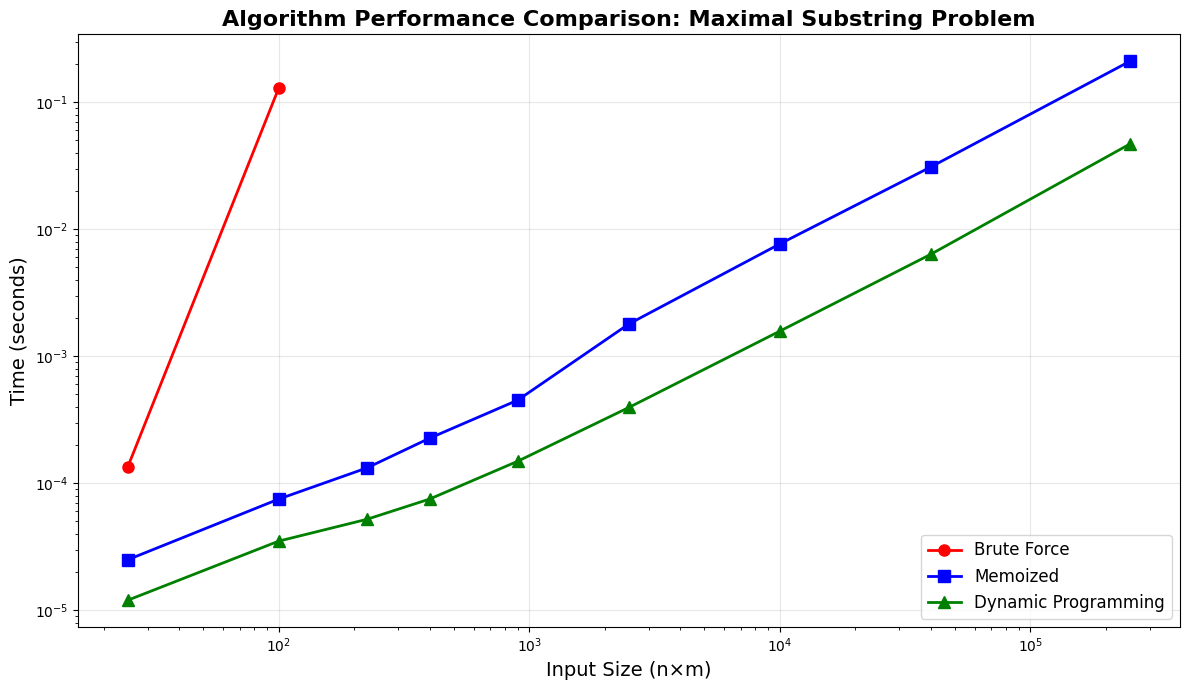


Observations:
1. Brute force becomes impractical very quickly (exponential growth)
2. Memoized and DP solutions show similar O(n×m) performance
3. DP is slightly faster due to iterative approach vs. recursive overhead


In [7]:
# Create benchmark graph
import matplotlib.pyplot as plt
import numpy as np

# Extract data for plotting
sizes = [r['n'] * r['m'] for r in benchmark_results]
bf_times = [float(r['BF Time (s)']) if r['BF Time (s)'] != "N/A" else None for r in benchmark_results]
memo_times = [float(r['Memo Time (s)']) if r['Memo Time (s)'] != "N/A" else None for r in benchmark_results]
dp_times = [float(r['DP Time (s)']) if r['DP Time (s)'] != "N/A" else None for r in benchmark_results]

# Create the plot
plt.figure(figsize=(12, 7))

# Plot each algorithm
if any(bf_times):
    valid_bf = [(s, t) for s, t in zip(sizes, bf_times) if t is not None]
    if valid_bf:
        sizes_bf, times_bf = zip(*valid_bf)
        plt.plot(sizes_bf, times_bf, 'ro-', label='Brute Force', linewidth=2, markersize=8)

if any(memo_times):
    valid_memo = [(s, t) for s, t in zip(sizes, memo_times) if t is not None]
    if valid_memo:
        sizes_memo, times_memo = zip(*valid_memo)
        plt.plot(sizes_memo, times_memo, 'bs-', label='Memoized', linewidth=2, markersize=8)

if any(dp_times):
    valid_dp = [(s, t) for s, t in zip(sizes, dp_times) if t is not None]
    if valid_dp:
        sizes_dp, times_dp = zip(*valid_dp)
        plt.plot(sizes_dp, times_dp, 'g^-', label='Dynamic Programming', linewidth=2, markersize=8)

plt.xlabel('Input Size (n×m)', fontsize=14)
plt.ylabel('Time (seconds)', fontsize=14)
plt.title('Algorithm Performance Comparison: Maximal Substring Problem', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Use log scale for better visibility
plt.xscale('log')
plt.tight_layout()
plt.show()

print("\nObservations:")
print("1. Brute force becomes impractical very quickly (exponential growth)")
print("2. Memoized and DP solutions show similar O(n×m) performance")
print("3. DP is slightly faster due to iterative approach vs. recursive overhead")